*Name* : - -

*Roll No.* : - -

Acknowledgement :- ChatGPT was used to assist in making this journal report

# **Mach Zehnder Interferometer**

## Calculations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
observations = pd.read_excel('Expt_2.xlsx')

delta_P = np.array(observations['Change in Pressure'])
delta_n = np.array(observations['Number of fringes'])

print("Change in Pressure (delta_P):", delta_P)
print("Number of Fringes (delta_n):", delta_n)


Change in Pressure (delta_P): [300 280 260 240 220 200 180 160 140 120 100]
Number of Fringes (delta_n): [14 12 11 10  9  8  8  7  6  6  5]


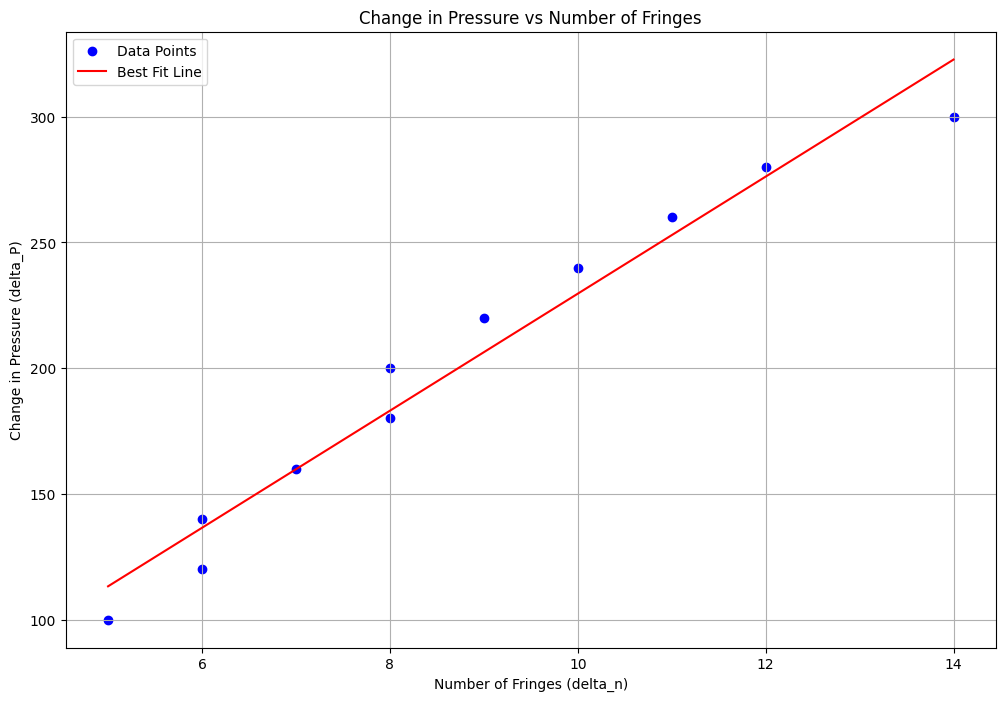

In [ ]:
constants = {
    'wavelength': 635e-9,  # Wavelength of light in meters (e.g., 632.8 nm for He-Ne laser)
    'length': 0.09,            # Length of the air column in meters
}

fitting = np.polyfit(delta_n, delta_P, 1)
slope = fitting[0]
del_slope = np.sqrt(np.sum((delta_n - np.poly1d(fitting)(delta_n))**2) / (len(delta_n) - 2)) / np.sqrt(np.sum((delta_n - np.mean(delta_n))**2))


plt.figure(figsize=(12, 8))
plt.scatter(delta_n, delta_P, color='blue', label='Data Points')
plt.plot(delta_n, np.poly1d(fitting)(delta_n), color='red', label='Best Fit Line')
plt.title('Change in Pressure vs Number of Fringes')
plt.xlabel('Number of Fringes (delta_n)')
plt.ylabel('Change in Pressure (delta_P)')
plt.grid()
plt.legend()
plt.show() 

In [4]:
k = constants['wavelength'] / (constants['length'] * fitting[0])
print(f"Calculated value of k: {k:.4e}")

del_k = (constants['wavelength'] / (constants['length'] * slope**2)) * del_slope
print(f"Uncertainty in k del_k: {del_k:.4e}")

print(f"Error: {del_k / k  * 100:.2f}%")

n_air = 1 + k*760
print(f"Refractive index of air: {n_air:.6f}")

Calculated value of k: 3.0309e-07
Uncertainty in k del_k: 3.2604e-07
Error: 107.57%
Refractive index of air: 1.000230
